## Which region needs help first???


High res imagery from drones or satellites post natural disaster to predict which areas require the most emergency aid to help direct first responders
Population data overlay to help optimize the best places to send aid

Split aerial image to 12 grids and rate the grids 1 to 12 in terms of which needs help the most

In [72]:
import numpy as np
import torch
import torch.nn as nn
import torch.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import os
import zipfile
import random
import time
from pathlib import Path
from collections import Counter
import pandas as pd

from PIL import Image, ImageFile
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

ImageFile.LOAD_TRUNCATED_IMAGES = True

seed=67
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

In [73]:
from google.colab import drive, files
from pathlib import Path
import shutil

drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/NatDisaster")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = DRIVE_DIR / "NatDisaster.zip"
MODELS_DIR = DRIVE_DIR / "models"
RESULTS_DIR = DRIVE_DIR / "results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
EXTRACT_DIR = Path("/content/natdisaster_data")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print(f"Extracted {ZIP_PATH} to {EXTRACT_DIR}")
print("Top-level extracted files/folders:")
for path in sorted(EXTRACT_DIR.iterdir()):
    print("-", path)

Extracted /content/drive/MyDrive/NatDisaster/NatDisaster.zip to /content/natdisaster_data
Top-level extracted files/folders:
- /content/natdisaster_data/NatDistaster
- /content/natdisaster_data/__MACOSX


In [75]:
def find_dataset_root(base_dir):
    base_dir = Path(base_dir)
    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if (candidate / "Disaster").is_dir() and (candidate / "Normal").is_dir():
            return candidate

DATASET_ROOT = find_dataset_root(EXTRACT_DIR)
class_to_label = {"Normal": 0, "Disaster": 1}
LABEL_TO_CLASS = {v: k for k, v in class_to_label.items()}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows = []
for class_name, label in class_to_label.items():
    folder = DATASET_ROOT / class_name
    for path in folder.iterdir():
        if path.suffix.lower() in IMAGE_EXTENSIONS:
            rows.append({"path": str(path), "class_name": class_name, "label": label})

df = pd.DataFrame(rows)

print("Dataset root:", DATASET_ROOT)
display(df["class_name"].value_counts())
df.head()

Dataset root: /content/natdisaster_data/NatDistaster


,count
class_name,
Normal,13207
Disaster,1828


,path,class_name,label
0,/content/natdisaster_data/NatDistaster/Normal/...,Normal,0
1,/content/natdisaster_data/NatDistaster/Normal/...,Normal,0
2,/content/natdisaster_data/NatDistaster/Normal/...,Normal,0
3,/content/natdisaster_data/NatDistaster/Normal/...,Normal,0
4,/content/natdisaster_data/NatDistaster/Normal/...,Normal,0


In [76]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'],
    random_state=seed
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'],
    random_state=seed
)
splits = pd.DataFrame({
    'train': train_df['class_name'].value_counts(),
    'val': val_df['class_name'].value_counts(),
    'test': test_df['class_name'].value_counts()
}).fillna(0).astype(int)

display(splits)

,train,val,test
class_name,,,
Normal,9244,1981,1982
Disaster,1280,274,274


In [102]:
image_size=224
batch_size=64
epochs=10
lr = 1e-5
weight_decay = 1e-4
num_workers = 2

minority_train_count = train_df['label'].value_counts().min()
balanced_samples_per_epoch = 2*minority_train_count
print(balanced_samples_per_epoch)

2560


In [78]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.ColorJitter(brightness=0.15, contrast = 0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize(int(image_size * 1.14)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [79]:
class NatDisasterData(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image_path = row['path']
        label = int(row['label'])
        with Image.open(image_path) as image:
            image = image.convert("RGB")
        return self.transform(image), label


In [80]:
train_dataset = NatDisasterData(train_df, train_transform)
val_dataset = NatDisasterData(val_df, eval_transform)
test_dataset = NatDisasterData(test_df, eval_transform)
class_counts = Counter(train_df['label'].tolist())
sample_weights = [1.0 / class_counts[label] for label in train_df['label'].tolist()]

sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples = balanced_samples_per_epoch,
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers = num_workers,
    pin_memory = torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers = num_workers,
    pin_memory = torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers = num_workers,
    pin_memory = torch.cuda.is_available()
)

len(train_loader), len(val_loader), len(test_loader)


(40, 36, 36)

In [108]:
def build_cnn(num_classes=2):
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    model = models.convnext_tiny(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

def build_vit(num_classes=2):
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model


In [110]:
model_builders = {"cnn_convnext_tiny": build_cnn, "vit_b_16": build_vit}
model_builders.keys()

dict_keys(['cnn_convnext_tiny', 'vit_b_16'])

In [99]:
def metrics(y_true, y_prob, threshold=0.5):
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    sample_weights = np.where(np.array(y_true) == 1, 10.0, 1.0)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "weighted_accuracy": accuracy_score(y_true, y_pred, sample_weight=sample_weights),
        "precision_disaster": precision_score(y_true, y_pred, zero_division=0),
        "recall_disaster": recall_score(y_true, y_pred, zero_division=0),
        "f1_disaster": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0,1]).tolist()
    }
    if len(set(y_true)) == 2:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        metrics["average_precision"] = average_precision_score(y_true, y_prob)
    else:
        metrics['roc_auc']=None
        metrics["average_precision"]=None

    return metrics



In [97]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_prob = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)[:,1]
        total_loss += loss.item() * labels.size(0)
        y_true.extend(labels.cpu().numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())

    metricres = metrics(y_true, y_prob)
    metricres['loss'] = total_loss / max(1,len(y_true))
    return metricres, np.array(y_true), np.array(y_prob)

In [85]:
print(train_df.columns.tolist())

['path', 'class_name', 'label']


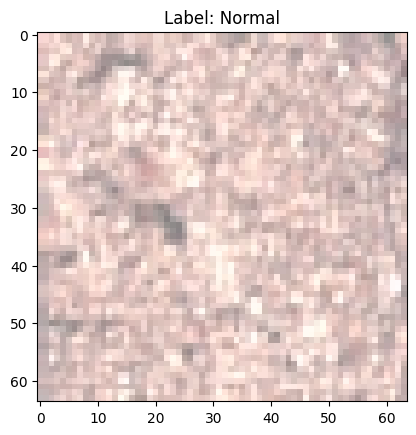

In [86]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

index = torch.randint(0, 10000, (1,)).item()
first_image_path = train_df['path'].iloc[index]

img = mpimg.imread(first_image_path)
plt.imshow(img)
plt.title(f"Label: {train_df['class_name'].iloc[0]}")
plt.show()

In [113]:
%%time

def train(model_name):
    print('\n' + '=' * 80)
    print(f"training {model_name}")
    model = model_builders[model_name]().to(device)
    counts = train_df['label'].value_counts().sort_index()
    class_weights = torch.tensor([1 / counts[0], 1/counts[1]], dtype=torch.float32)
    class_weights = class_weights / class_weights.sum() * 2
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    best_f1=-1
    history = []
    best_path = Path(f"/content/{model_name}_best.pt")

    for epoch in range(1, epochs+1):
        model.train()
        train_loss_sum = 0.0
        seen = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_sum += loss.item() * labels.size(0)
            seen += labels.size(0)

        scheduler.step()
        train_loss = train_loss_sum / max(1,seen)
        val_metrics, _, _ = evaluate(model, val_loader, criterion)

        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items() if k != "confusion_matrix"}
        }
        history.append(row)

        print(
            f"epoch{epoch} / {epochs} | "
            f"train_loss = {train_loss:.4f} | "
            f"val_weighted_acc = {val_metrics['weighted_accuracy']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1 = {val_metrics['f1_disaster']:.4f} | "
        )

        if val_metrics['f1_disaster'] > best_f1:
            best_f1 = val_metrics["f1_disaster"]
            torch.save({
                "model_name": model_name,
                "state_dict": model.state_dict(),
                "image_size": image_size,
                "class_to_label": class_to_label,
                "val_metrics": val_metrics,
            }, best_path)


    history_df = pd.DataFrame(history)
    history_df.to_csv(f"/content/{model_name}_history.csv", index=False)
    history_df.to_csv(RESULTS_DIR / f"{model_name}_history.csv", index=False)
    return model_name, best_path, history_df







CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 12.2 µs


In [116]:
train_models = []
cnn_result = train("cnn_convnext_tiny")
train_models.append(cnn_result)

cnn_result



training cnn_convnext_tiny


<timed exec>:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
<timed exec>:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


epoch1 / 10 | train_loss = 0.2230 | val_weighted_acc = 0.9682 | val_acc=0.9335 | val_f1 = 0.7851 | 


<timed exec>:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


epoch2 / 10 | train_loss = 0.0469 | val_weighted_acc = 0.9956 | val_acc=0.9907 | val_f1 = 0.9631 | 


...

<timed exec>:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


epoch9 / 10 | train_loss = 0.0031 | val_weighted_acc = 0.9998 | val_acc=0.9996 | val_f1 = 0.9982 | 


<timed exec>:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


epoch10 / 10 | train_loss = 0.0033 | val_weighted_acc = 0.9998 | val_acc=0.9996 | val_f1 = 0.9982 | 


('cnn_convnext_tiny',
 PosixPath('/content/cnn_convnext_tiny_best.pt'),
                model  epoch  train_loss  val_accuracy  val_weighted_accuracy  \
 0  cnn_convnext_tiny      1    0.223021      0.933481               0.968227   
 1  cnn_convnext_tiny      2    0.046928      0.990687               0.995552   
 2  cnn_convnext_tiny      3    0.018096      0.997339               0.998729   
 3  cnn_convnext_tiny      4    0.008133      0.998226               0.999153   
 4  cnn_convnext_tiny      5    0.005877      0.997783               0.998941   
 5  cnn_convnext_tiny      6    0.004097      0.997783               0.998941   
 6  cnn_convnext_tiny      7    0.003335      0.999557               0.999788   
 7  cnn_convnext_tiny      8    0.003760      0.999557               0.999788   
 8  cnn_convnext_tiny      9    0.003148      0.999557               0.999788   
 9  cnn_convnext_tiny     10    0.003281      0.999557               0.999788   
 
    val_precision_disaster  val_rec

In [123]:
import gc
import torch

try:
    del model
except NameError:
    pass

try:
    del cnn_result
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

In [124]:
vit_result = train("vit_b_16")
train_models.append(vit_result)
train_models



training vit_b_16


<timed exec>:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
<timed exec>:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


epoch1 / 10 | train_loss = 0.1052 | val_weighted_acc = 0.9989 | val_acc=0.9978 | val_f1 = 0.9910 | 


<timed exec>:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


epoch2 / 10 | train_loss = 0.0034 | val_weighted_acc = 0.9998 | val_acc=0.9996 | val_f1 = 0.9982 | 


...

<timed exec>:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


epoch9 / 10 | train_loss = 0.0003 | val_weighted_acc = 1.0000 | val_acc=1.0000 | val_f1 = 1.0000 | 


<timed exec>:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


epoch10 / 10 | train_loss = 0.0004 | val_weighted_acc = 1.0000 | val_acc=1.0000 | val_f1 = 1.0000 | 


[('cnn_convnext_tiny',
  PosixPath('/content/cnn_convnext_tiny_best.pt'),
                 model  epoch  train_loss  val_accuracy  val_weighted_accuracy  \
  0  cnn_convnext_tiny      1    0.223021      0.933481               0.968227   
  1  cnn_convnext_tiny      2    0.046928      0.990687               0.995552   
  2  cnn_convnext_tiny      3    0.018096      0.997339               0.998729   
  3  cnn_convnext_tiny      4    0.008133      0.998226               0.999153   
  4  cnn_convnext_tiny      5    0.005877      0.997783               0.998941   
  5  cnn_convnext_tiny      6    0.004097      0.997783               0.998941   
  6  cnn_convnext_tiny      7    0.003335      0.999557               0.999788   
  7  cnn_convnext_tiny      8    0.003760      0.999557               0.999788   
  8  cnn_convnext_tiny      9    0.003148      0.999557               0.999788   
  9  cnn_convnext_tiny     10    0.003281      0.999557               0.999788   
  
     val_precision_di

,model,epoch,train_loss,val_accuracy,val_weighted_accuracy,val_precision_disaster,val_recall_disaster,val_f1_disaster,val_roc_auc,val_average_precision,val_loss
0,cnn_convnext_tiny,1,0.223021,0.933481,0.968227,0.646226,1.0,0.785100,0.998266,0.988792,0.173594
1,cnn_convnext_tiny,2,0.046928,0.990687,0.995552,0.928814,1.0,0.963093,0.999888,0.999191,0.041009
2,cnn_convnext_tiny,3,0.018096,0.997339,0.998729,0.978571,1.0,0.989170,0.999989,0.999920,0.014420
3,cnn_convnext_tiny,4,0.008133,0.998226,0.999153,0.985612,1.0,0.992754,0.999996,0.999973,0.008729
4,cnn_convnext_tiny,5,0.005877,0.997783,0.998941,0.982079,1.0,0.990958,0.999998,0.999987,0.006798
5,cnn_convnext_tiny,6,0.004097,0.997783,0.998941,0.982079,1.0,0.990958,1.000000,1.000000,0.005559
6,cnn_convnext_tiny,7,0.003335,0.999557,0.999788,0.996364,1.0,0.998179,1.000000,1.000000,0.004205
7,cnn_convnext_tiny,8,0.003760,0.999557,0.999788,0.996364,1.0,0.998179,1.000000,1.000000,0.003710
8,cnn_convnext_tiny,9,0.003148,0.999557,0.999788,0.996364,1.0,0.998179,1.000000,1.000000,0.003506
9,cnn_convnext_tiny,10,0.003281,0.999557,0.999788,0.996364,1.0,0.998179,1.000000,1.000000,0.003481


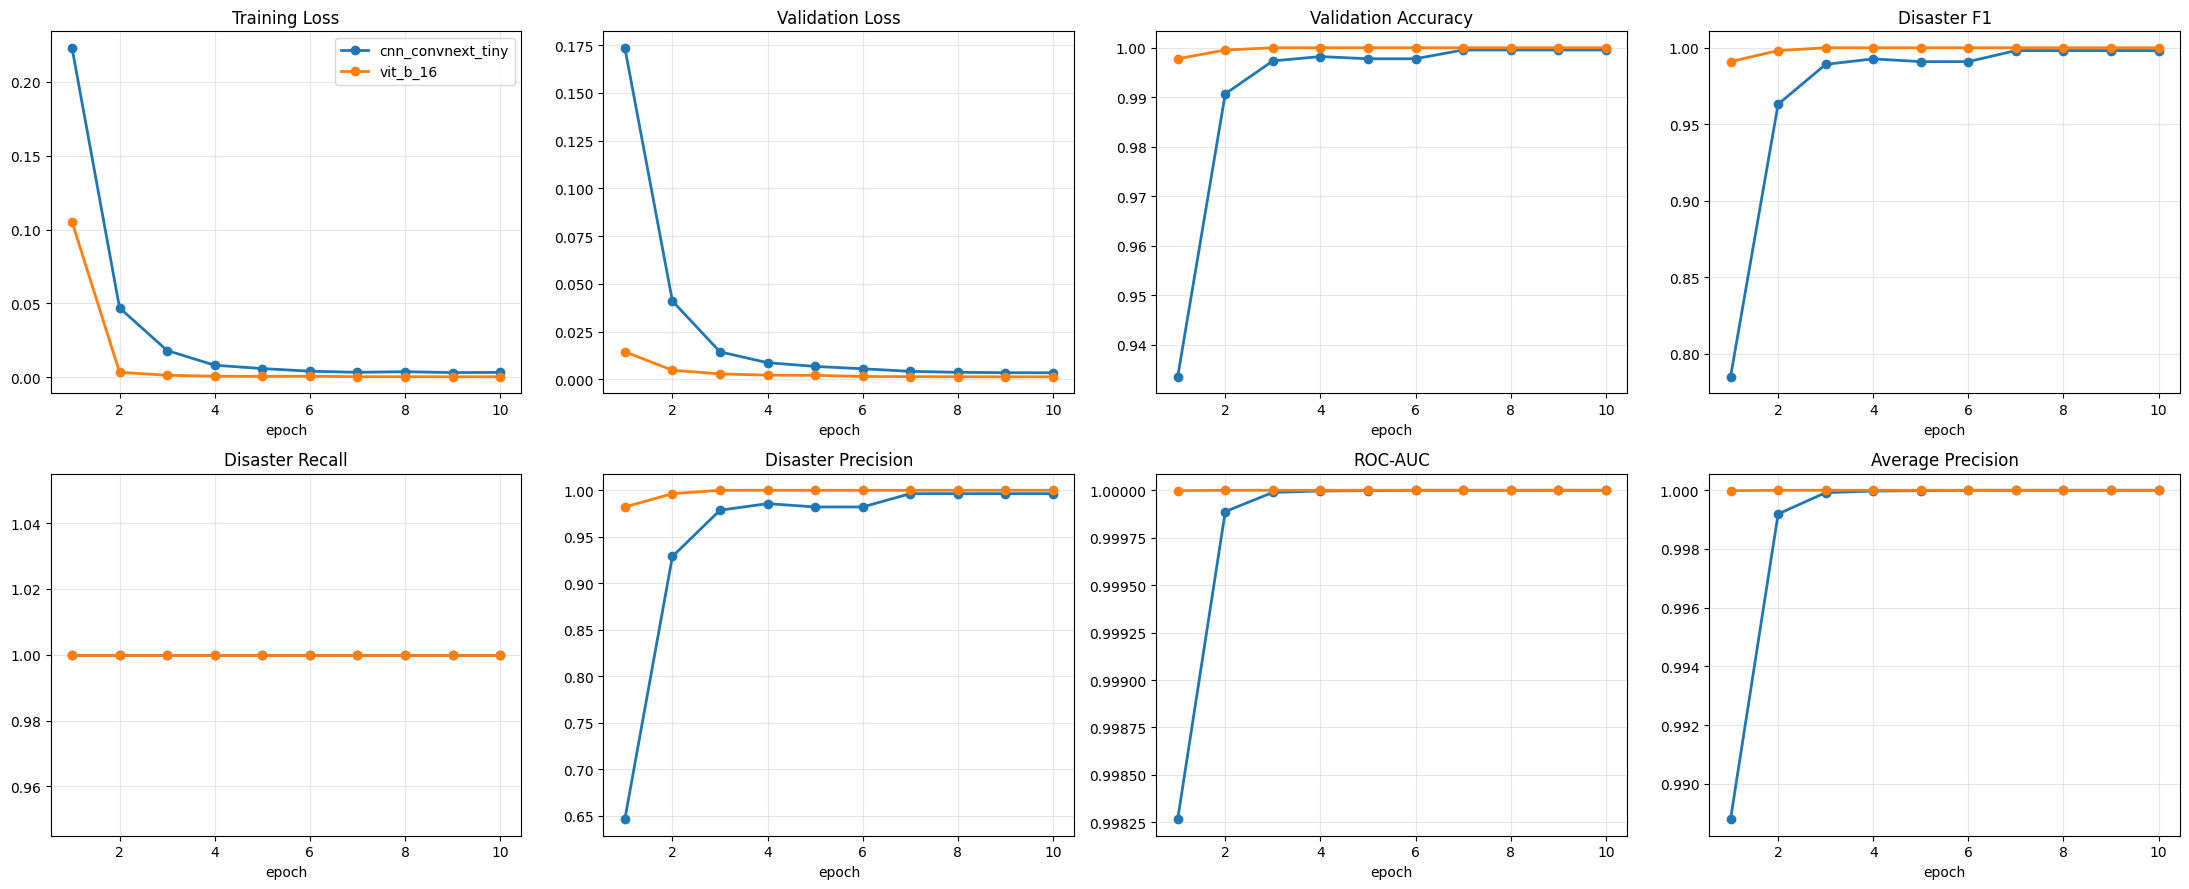

In [126]:
history_df = pd.concat([result[2] for result in train_models], ignore_index=True)
display(history_df)

history_df.to_csv("/content/cnn_vs_vit_epoch_history.csv", index=False)
history_df.to_csv(RESULTS_DIR / "cnn_vs_vit_epoch_history.csv", index=False)

metrics_to_plot = [
    ("train_loss", "Training Loss"),
    ("val_loss", "Validation Loss"),
    ("val_accuracy", "Validation Accuracy"),
    ("val_f1_disaster", "Disaster F1"),
    ("val_recall_disaster", "Disaster Recall"),
    ("val_precision_disaster", "Disaster Precision"),
    ("val_roc_auc", "ROC-AUC"),
    ("val_average_precision", "Average Precision")
]

fig,axes = plt.subplots(2,4,figsize=(22,9))
axes = axes.flatten()
for ax, (metric, title) in zip(axes, metrics_to_plot):
    for model_name, model_history in history_df.groupby("model"):
        ax.plot(
            model_history["epoch"],
            model_history[metric],
            marker='o',
            linewidth=2,
            label=model_name
        )
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()

In [134]:
MODELS_DIR = Path("/content/drive/MyDrive/NatDisaster/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
exported_model_paths = []
for model_name, checkpoint_path, history_df_one_model in train_models:
    checkpoint_path = Path(checkpoint_path)
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )
    export_path = MODELS_DIR / f"{model_name}_natdisaster.pth"

    torch.save({
        "model_name": checkpoint["model_name"],
        "state_dict": checkpoint["state_dict"],
        "image_size": checkpoint["image_size"],
        "class_to_label": checkpoint["class_to_label"],
        "label_to_class": {v: k for k, v in checkpoint["class_to_label"].items()},
        "val_metrics": checkpoint["val_metrics"]
    }, export_path)

    exported_model_paths.append(export_path)

exported_model_paths

[PosixPath('/content/drive/MyDrive/NatDisaster/models/cnn_convnext_tiny_natdisaster.pth'),
 PosixPath('/content/drive/MyDrive/NatDisaster/models/vit_b_16_natdisaster.pth')]

In [135]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def load_checkpoint(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )
    model_name = checkpoint["model_name"]
    model = model_builders[model_name]().to(device)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model_name, model, checkpoint



In [136]:
test_results = []
test_curves = {}
criterion = nn.CrossEntropyLoss()
for model_name, checkpoint_path, history_df_one_model in train_models:
    model_name, model, checkpoint = load_checkpoint(checkpoint_path)
    test_metrics, y_true, y_prob = evaluate(model, test_loader, criterion)
    test_curves[model_name] = (y_true, y_prob)
    test_results.append({
        "model": model_name,
        **test_metrics
    })


results_df = pd.DataFrame(test_results)
display(results_df.drop(columns=["confusion_matrix"]))

,model,accuracy,weighted_accuracy,precision_disaster,recall_disaster,f1_disaster,roc_auc,average_precision,loss
0,cnn_convnext_tiny,0.999557,0.997882,1.0,0.99635,0.998172,0.999998,0.999987,0.004486
1,vit_b_16,0.999557,0.997882,1.0,0.99635,0.998172,1.000000,1.000000,0.003995


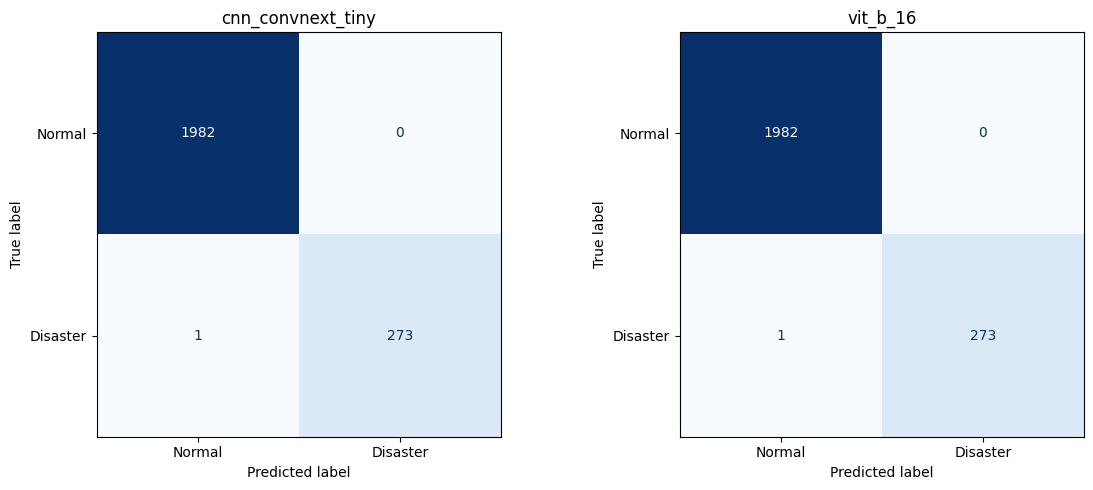

In [137]:
fig, axes = plt.subplots(1, len(test_results), figsize=(6*len(test_results), 5))
if len(test_results)==1:
    axes=[axes]

for ax,row in zip(axes, test_results):
    cm = np.array(row["confusion_matrix"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels = ["Normal", "Disaster"]
    )
    disp.plot(ax=ax, cmap="Blues",values_format="d", colorbar=False)
    ax.set_title(row["model"])

plt.tight_layout()
plt.show()